In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import ClusterCentroids

from sklearn.cluster import KMeans
from collections import Counter

np.random.seed(0) # For reproducibility
sns.set(style="whitegrid")

## Part A: Baseline Model and Data Analysis (Borrowed from A3)

### Data Loading and Analysis

In [2]:
# Load the dataset
df = pd.read_csv(r"creditcard.csv")

print("Number of datapoints: ", df.shape[0])
print("Number of features: ", df.shape[1])

Number of datapoints:  284807
Number of features:  31


**From the analysis made in earlier assignment, the data doesn't have any missing values or doesn't need any further processing**

In [3]:
# Distribution of classes
num_frauds, num_non_frauds = sum(df['Class']), sum(1 - df['Class'])
print("Number of fraudulents: ", num_frauds)
print("Number of Non-Fraud: ", num_non_frauds)
print("\n")
print("Degree of Imbalance(Non-Fraud : Fraud ratio): ", num_non_frauds / num_frauds)

Number of fraudulents:  492
Number of Non-Fraud:  284315


Degree of Imbalance(Non-Fraud : Fraud ratio):  577.8760162601626


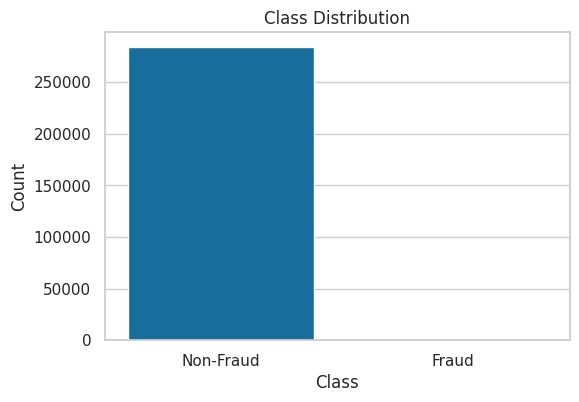

In [4]:
# Bar plot
class_counts = df['Class'].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="colorblind", hue=class_counts.index, legend=False)
plt.xticks([0,1], ["Non-Fraud", "Fraud"])
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

### Model Training

In [5]:
# Splitting the data, preserving class imbalance
X = np.array(df.drop("Class", axis=1))
y = np.array(df["Class"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)

# Degree of Imbalance
print("Degree of Imbalance in Train set: ", sum(1 - y_train) / sum(y_train))
print("Degree of Imbalance in Test set: ", sum(1 - y_test) / sum(y_test))

Degree of Imbalance in Train set:  577.8753387533875
Degree of Imbalance in Test set:  577.8780487804878


In [6]:
# Baseline Model
baseline_model = LogisticRegression(max_iter=1000, random_state=0, solver="newton-cholesky")
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

In [7]:
print("Baseline Logistic Regression - Classification Report")
print("\n")
print(classification_report(y_test, y_pred_base, digits=4))
print("Accuracy:", accuracy_score(y_test, y_pred_base))

Baseline Logistic Regression - Classification Report


              precision    recall  f1-score   support

           0     0.9994    0.9998    0.9996     71079
           1     0.8526    0.6585    0.7431       123

    accuracy                         0.9992     71202
   macro avg     0.9260    0.8292    0.8714     71202
weighted avg     0.9992    0.9992    0.9992     71202

Accuracy: 0.9992135052386169


**The Accuracy is not a good metric here, because the Degree of Imbalance is $\approx$ 578 i.e. there are 578 non-fraud cases per fraud case. So even if the model outputs 0 (predicts everyone as non-fraud), the accuracy would be around 578/579 $\approx$ 0.998. The better metrics to look at here would be recall (actual number of frauds catched) and precision (how reliable the model when the output is 1) and F1 score which balances between recall and precision**

## Part B: Gaussian Mixture Model (GMM) for Synthetic Sampling

### Theoretical Foundation

### Difference between SMOTE and GMM Sampling

**SMOTE:**  
- Generates synthetic points by linear interpolation between a sample $x_i$ and one of its neighbors $x_j$:  

$x_{\text{new}} = x_i + \lambda (x_j - x_i), \quad \lambda \sim \mathcal{U}(0,1)$

- This produces samples uniformly in the **convex hull** of existing minority points.  
- If the true distribution is **non-convex** or **multi-modal**, SMOTE may generate samples in **low-density regions**, introducing noise.

**GMM Sampling:**  
- Models the minority class as a mixture of Gaussians:  

$p(x) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x \mid \mu_k, \Sigma_k)$

where $\pi_k$ are mixture weights, $\mu_k$ means, and $\Sigma_k$ covariances.  
- Synthetic samples are drawn by:  
  1. Sampling a component $z \sim \text{Categorical}(\pi)$  
  2. Sampling $x \sim \mathcal{N}(\mu_z, \Sigma_z)$

- This respects the **multi-modal structure** of the data, generating points only in regions of high probability density.  

### GMM Implementation

In [8]:
X_minority = X_train[y_train == 1]
print("Size of minority class: ", len(X_minority))

Size of minority class:  369


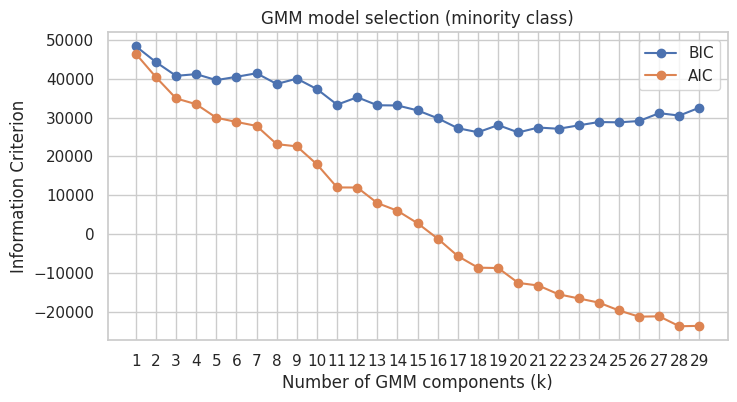

In [9]:
# Determining the best model using BIC/AIC
bics, aics = [], []
n_comps = range(1, 30)
for n in n_comps:
    gmm = GaussianMixture(n_components=n, covariance_type="full", random_state=0, n_init=5)
    gmm.fit(X_minority)
    bics.append(gmm.bic(X_minority))
    aics.append(gmm.aic(X_minority))

plt.figure(figsize=(8,4))
plt.plot(list(n_comps), bics, marker='o', label='BIC')
plt.plot(list(n_comps), aics, marker='o', label='AIC')
plt.xlabel('Number of GMM components (k)')
plt.ylabel('Information Criterion')
plt.title('GMM model selection (minority class)')
plt.legend()
plt.xticks(list(n_comps))
plt.show()

In [10]:
# Training the best model
best_n = 18
gmm = GaussianMixture(n_components=best_n, covariance_type="full", random_state=0, n_init=5)
gmm.fit(X_minority)

GaussianMixture(n_components=18, n_init=5, random_state=0)

### Synthetic Data Generation

In [11]:
samples_needed = round((X_train[y_train == 0].shape[0] / 10)) - X_minority.shape[0]

# Oversample with GMM
X_syn, _ = gmm.sample(samples_needed)
X_minority_gmm = np.concatenate([X_minority, X_syn])
y_minority_gmm = np.ones(len(X_minority) + samples_needed)

# Combine
X_train_gmm = np.concatenate([X_minority_gmm, X_train[y_train == 0]])
y_train_gmm = np.concatenate([y_minority_gmm, np.zeros(X_train[y_train == 0].shape[0])])

# Shuffle
idx = np.random.permutation(len(y_train_gmm))
X_train_gmm = X_train_gmm[idx]
y_train_gmm = y_train_gmm[idx]

In [12]:
# Degree of imbalance after Oversampling
print("Degree of Imbalance in Train set after oversampling: ", sum(1 - y_train_gmm) / sum(y_train_gmm))

Degree of Imbalance in Train set after oversampling:  9.999812417932846


### Rebalancing with CBU

In [13]:
# Size of majority class 
print("Size of the majority class: ", len(X_train[y_train == 0]))

Size of the majority class:  213236


**Meanwhile. size of the minority class is 369 estimated by a GMM with 18 components so each gaussian component on average models 20 points, Let's try to sample 100 points from each gaussians, a value too low would be under-representative, while something too high would end up with more samples from low probability regions leading to noise.**

**Therefore, I'm aiming to have 2k samples in minority class and an imbalace ratio of 1:10 would be reasonable so, 20k samples from majority class**

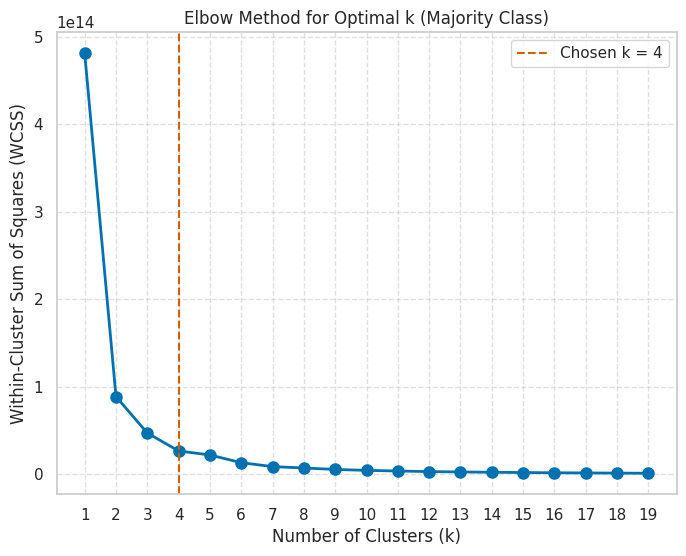

In [14]:
# CBU
majority = X_train[y_train==0]

wc_ss = []
K = range(1, 20)
for i in K:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(majority)
    wc_ss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K, wc_ss, 'o-', color="#0072B2", markersize=8, linewidth=2)
plt.xticks(K)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method for Optimal k (Majority Class)")
plt.grid(True, linestyle="--", alpha=0.6)

optimal_k = 4
plt.axvline(x=optimal_k, color="#D55E00", linestyle="--", label=f"Chosen k = {optimal_k}")
plt.legend()
plt.show()

In [15]:
k_major = 4
kmeans_major = KMeans(n_clusters=k_major, random_state=42)
clusters_major = kmeans_major.fit_predict(majority)

# Undersample proportionally
target_majority_size = 20000
X_majority_sampled = []
y_majority_sampled = []

for cluster_id in range(k_major):
    cluster_samples = majority[clusters_major == cluster_id]
    n_samples_keep = int(len(cluster_samples) * target_majority_size / len(majority))
    indices = np.random.choice(cluster_samples.shape[0], size=n_samples_keep, replace=True)
    sampled = cluster_samples[indices]
    X_majority_sampled.append(sampled)
    y_majority_sampled.append(np.array([0]*n_samples_keep))

X_majority_final = np.concatenate(X_majority_sampled)
y_majority_final = np.concatenate(y_majority_sampled)

In [16]:
# Oversample with GMM
target_minority_size = 2000
samples_needed = target_minority_size - len(X_minority)
X_syn, _ = gmm.sample(target_minority_size)
X_minority_final = np.concatenate([X_syn, X_minority])
y_minority_final = np.ones(target_minority_size)

# Combine
X_train_cbu_gmm = np.concatenate([X_minority_final, X_majority_final])
y_train_cbu_gmm = np.concatenate([y_minority_final, y_majority_final])

# Shuffle
idx = np.random.permutation(len(y_train_cbu_gmm))
X_train_cbu_gmm = X_train_cbu_gmm[idx]
y_train_cbu_gmm = y_train_cbu_gmm[idx]

In [17]:
# Degree of imbalance after Oversampling with GMM and Undersampling with CBU
print("Degree of Imbalance in Train set after GMM+CBU: ", sum(1 - y_train_cbu_gmm) / sum(y_train_cbu_gmm))

Degree of Imbalance in Train set after GMM+CBU:  9.999


## Part C: Performace Evaluation and Conclusion

### Model Training and Evaluation

In [18]:
# With just oversampling with GMM
model_gmm = LogisticRegression(max_iter=1000, random_state=0, solver="newton-cholesky")
model_gmm.fit(X_train_gmm, y_train_gmm)
y_pred_gmm = model_gmm.predict(X_test)

In [19]:
# With just oversampling with GMM and undersampling CBU
model_cbu_gmm = LogisticRegression(max_iter=1000, random_state=0, solver="newton-cholesky")
model_cbu_gmm.fit(X_train_cbu_gmm, y_train_cbu_gmm)
y_pred_cbu_gmm = model_cbu_gmm.predict(X_test)

### Comparative Analysis

In [20]:
# Collect predictions
models = {
    "Baseline": y_pred_base,
    "GMM": y_pred_gmm,
    "GMM + CBU": y_pred_cbu_gmm
}

# Build summary table for both classes
rows = []
for name, preds in models.items():
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, preds, average=None, labels=[0,1])
    rows.append([name, "Majority (0)", precision[0], recall[0], f1[0]])
    rows.append([name, "Minority (1)", precision[1], recall[1], f1[1]])

summary_df = pd.DataFrame(rows, columns=["Model","Class","Precision","Recall","F1-score"])
print(summary_df)

       Model         Class  Precision    Recall  F1-score
0   Baseline  Majority (0)   0.999409  0.999803  0.999606
1   Baseline  Minority (1)   0.852632  0.658537  0.743119
2        GMM  Majority (0)   0.999718  0.998846  0.999282
3        GMM  Minority (1)   0.556757  0.837398  0.668831
4  GMM + CBU  Majority (0)   0.999437  0.999353  0.999395
5  GMM + CBU  Minority (1)   0.643411  0.674797  0.658730


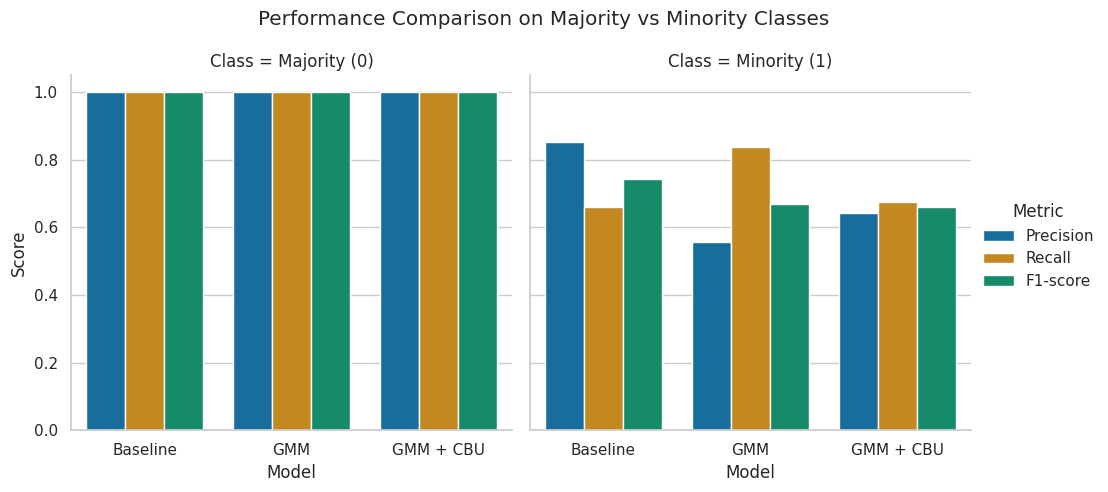

In [21]:
summary_melted = summary_df.melt(id_vars=["Model","Class"], var_name="Metric", value_name="Score")

g = sns.catplot(
    data=summary_melted,
    x="Model", y="Score", hue="Metric",
    col="Class",
    kind="bar",
    palette="colorblind",
    height=5, aspect=1
)

g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Performance Comparison on Majority vs Minority Classes")
plt.show()

### Final Recommendation

The experiments show that **baseline training on imbalanced data** leads to very poor recall for the fraud class (most frauds are missed).  
Using **GMM-based oversampling** improves recall significantly, though at the cost of lower precision (more false alarms).  
Combining **GMM with clustering-based undersampling (CBU)** provides a more balanced trade-off between precision and recall.

**Which method to choose depends on the use case:**

- **High Precision Needed (minimize false positives):**  
  For scenarios like *person–merchant transactions*, a false alarm can damage customer trust or business relationships.  
  → Prefer methods that preserve **precision** (e.g., GMM + CBU).  

- **High Recall Needed (catch as many frauds as possible):**  
  For scenarios like *person–person transactions*, missing a fraud is more costly than flagging a legitimate one.  
  → Prefer methods that maximize **recall** (e.g., pure GMM oversampling).  

**Key point:**  
There is no one-size-fits-all solution. Fraud detection is inherently **cost-sensitive**, so the right resampling strategy depends on whether **false positives** or **false negatives** are more harmful. In practice, teams must experiment with multiple strategies and choose the one that best aligns with business priorities.  